# 02_treinamento_ml_v2 — Versão revisada

Ajustes feitos em relação à versão original, na ordem de prioridade:

1. **Vazamento de dados (leakage) no split treino/teste** — pedidos com múltiplos itens geravam mais de uma linha por `order_id`. O split original era por linha, então o mesmo pedido podia cair em treino **e** em teste ao mesmo tempo. Corrigido com `GroupShuffleSplit` agrupando por `order_id`.
2. **Estados raros gerando ruído** — UFs com poucos pedidos (ex: RR, AP, AC) viravam colunas dummy quase vazias. Agrupadas em `OUTRO` (o corte é calculado só no treino, para não vazar informação do teste).
3. **Nova feature de baixo custo: `mesma_uf`** — indicador simples de se vendedor e cliente estão no mesmo estado, como proxy barato de distância/complexidade da rota (sem explodir em uma dummy por rota).
4. **Calibração de probabilidade** — o modelo original gerava um `risco_atraso_perc` com média de ~40%, bem acima da taxa real de atraso (~6,6%). Isso é típico de Random Forest sem calibração e distorce qualquer card/KPI que use essa média no Power BI. Corrigido com `CalibratedClassifierCV` (isotonic).
5. **Threshold de decisão ajustável** — em vez de fixar o corte padrão em 0.5, calculamos o threshold que maximiza F1 da classe 'atraso' via curva precisão-recall, deixando explícito o trade-off precisão x recall para decisão do negócio.
6. **Feature importance exposta** — para saber o que de fato pesa na previsão (mês da compra domina a importância, o que bate com a sazonalidade vista na EDA).

**Limite importante:** mesmo com esses ajustes, o ROC-AUC fica em ~0.74 e o PR-AUC em ~0.19 — o teto é baixo porque as features atuais têm correlação individual muito fraca com o atraso real (como o próprio mapa de calor da EDA mostrou). Para um salto de performance real, o próximo passo é reaproveitar os dados brutos do Olist e adicionar:
- `order_estimated_delivery_date - order_purchase_timestamp` (o prazo prometido ao cliente — provavelmente a feature mais forte, e ainda assim sem leakage, pois é conhecida no momento da compra)
- distância real entre vendedor e cliente (via `olist_geolocation_dataset`)
- categoria do produto (`olist_products_dataset` tem `product_category_name`)


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/base_logistica_enriquecida.csv')

## 1. Split sem vazamento (agrupado por `order_id`)

In [2]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['order_id']))
df_train, df_test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

assert len(set(df_train.order_id) & set(df_test.order_id)) == 0, 'Ainda há vazamento entre treino e teste!'
print('Treino:', df_train.shape, '| Teste:', df_test.shape)

Treino: (77130, 13) | Teste: (33049, 13)


## 2. Features: agrupar UFs raras + feature `mesma_uf`

In [3]:
def group_rare(series, ref_counts, min_count=300):
    rare = ref_counts[ref_counts < min_count].index
    return series.where(~series.isin(rare), 'OUTRO')

ref_counts_seller = df_train['seller_state'].value_counts()
ref_counts_cust = df_train['customer_state'].value_counts()

for d in (df_train, df_test):
    d['seller_state_grp'] = group_rare(d['seller_state'], ref_counts_seller)
    d['customer_state_grp'] = group_rare(d['customer_state'], ref_counts_cust)
    d['mesma_uf'] = (d['seller_state'] == d['customer_state']).astype(int)

features_num = ['product_weight_g', 'volume_cm3', 'mes_compra', 'dia_semana_compra', 'mesma_uf']

def build_X(d, ref_cols=None):
    X = pd.get_dummies(d[['seller_state_grp', 'customer_state_grp']], drop_first=True)
    X[features_num] = d[features_num]
    if ref_cols is not None:
        X = X.reindex(columns=ref_cols, fill_value=0)
    return X

X_train = build_X(df_train)
X_test = build_X(df_test, ref_cols=X_train.columns)
y_train, y_test = df_train['houve_atraso'], df_test['houve_atraso']

## 3. Treinamento (Random Forest, mesma família do original)

In [4]:
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=20,   # reduz overfitting em folhas muito específicas
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

proba_teste = modelo_rf.predict_proba(X_test)[:, 1]
print('--- Threshold padrão (0.5) ---')
print(classification_report(y_test, (proba_teste >= 0.5).astype(int), digits=3))
print('ROC-AUC:', roc_auc_score(y_test, proba_teste))
print('PR-AUC:', average_precision_score(y_test, proba_teste))

--- Threshold padrão (0.5) ---
              precision    recall  f1-score   support

           0      0.963     0.782     0.863     30877
           1      0.155     0.568     0.244      2172

    accuracy                          0.768     33049
   macro avg      0.559     0.675     0.553     33049
weighted avg      0.910     0.768     0.822     33049

ROC-AUC: 0.7391208201423685
PR-AUC: 0.19083177970887424


## 4. Threshold ajustável (trade-off precisão x recall)
O threshold 0.5 não tem nada de especial aqui — ele foi otimizado abaixo para maximizar o F1 da classe 'atraso', mas o valor certo depende do custo de ação do negócio (ex: ligar para o cliente vs. deixar passar um atraso).

--- Threshold otimizado (0.563) ---
              precision    recall  f1-score   support

           0      0.958     0.866     0.910     30877
           1      0.195     0.462     0.274      2172

    accuracy                          0.839     33049
   macro avg      0.576     0.664     0.592     33049
weighted avg      0.908     0.839     0.868     33049



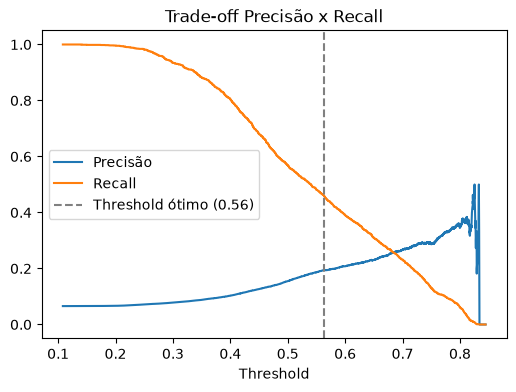

In [5]:
prec, rec, thr = precision_recall_curve(y_test, proba_teste)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_thr = thr[np.nanargmax(f1s[:-1])]

print(f'--- Threshold otimizado ({best_thr:.3f}) ---')
print(classification_report(y_test, (proba_teste >= best_thr).astype(int), digits=3))

plt.figure(figsize=(6,4))
plt.plot(thr, prec[:-1], label='Precisão')
plt.plot(thr, rec[:-1], label='Recall')
plt.axvline(best_thr, color='gray', linestyle='--', label=f'Threshold ótimo ({best_thr:.2f})')
plt.xlabel('Threshold'); plt.legend(); plt.title('Trade-off Precisão x Recall')
plt.show()

## 5. Calibração de probabilidade
Corrige a distorção do `risco_atraso_perc` (média ~40% no modelo original vs. ~6,6% de atraso real). Isso é o que garante que a média do score no Power BI reflita a taxa real de atraso.

In [6]:
modelo_calibrado = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=20,
                            random_state=42, class_weight='balanced', n_jobs=-1),
    method='isotonic', cv=3
)
modelo_calibrado.fit(X_train, y_train)
proba_cal = modelo_calibrado.predict_proba(X_test)[:, 1]

print('Média das probabilidades previstas (calibrado):', round(proba_cal.mean()*100, 2), '%')
print('Taxa real de atraso no teste:                  ', round(y_test.mean()*100, 2), '%')

Média das probabilidades previstas (calibrado): 6.61 %
Taxa real de atraso no teste:                   6.57 %


## 6. O que mais pesa na previsão

mes_compra               0.378947
volume_cm3               0.110687
product_weight_g         0.107557
customer_state_grp_SP    0.067394
customer_state_grp_RJ    0.059138
mesma_uf                 0.053296
dia_semana_compra        0.046899
customer_state_grp_MG    0.030650
customer_state_grp_PR    0.023059
seller_state_grp_SP      0.020564
dtype: float64


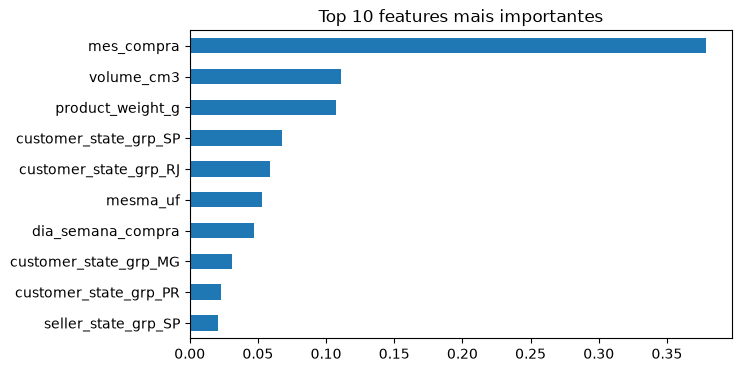

In [7]:
fi = pd.Series(modelo_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(fi.head(10))

plt.figure(figsize=(7,4))
fi.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 features mais importantes')
plt.show()

## 7. Exportação para o Power BI
Usa o modelo calibrado (probabilidades mais confiáveis) e adiciona também a marcação de 'alto risco' segundo o threshold ajustado, para já vir pronta a coluna binária de ação.

In [8]:
# Treina o modelo calibrado na base inteira para gerar o score final
modelo_final = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=20,
                            random_state=42, class_weight='balanced', n_jobs=-1),
    method='isotonic', cv=3
)

ref_counts_seller_full = df['seller_state'].value_counts()
ref_counts_cust_full = df['customer_state'].value_counts()
df['seller_state_grp'] = group_rare(df['seller_state'], ref_counts_seller_full)
df['customer_state_grp'] = group_rare(df['customer_state'], ref_counts_cust_full)
df['mesma_uf'] = (df['seller_state'] == df['customer_state']).astype(int)
X_full = build_X(df, ref_cols=X_train.columns)

modelo_final.fit(X_full, df['houve_atraso'])
probabilidades = modelo_final.predict_proba(X_full)[:, 1]

df_powerbi = df.copy()
df_powerbi['risco_atraso_perc'] = (probabilidades * 100).round(2)
df_powerbi['alto_risco'] = (probabilidades >= best_thr).astype(int)

caminho_bi = '../data/processed/base_para_powerbi.csv'
df_powerbi.to_csv(caminho_bi, index=False)
print('Base final exportada com risco calibrado e flag de alto risco:', caminho_bi)

Base final exportada com risco calibrado e flag de alto risco: ../data/processed/base_para_powerbi.csv
